# UAV Patrol — 2-UAV IPPO Training Notebook
> **Architecture**: Independent PPO (IPPO)  
> **Extension hooks**: MAPPO / VDPPO (commented stubs included)  
> **Observation**: 5×5 local window (80 features/agent)  
> **Shared world**: coverage_map · visit_count · obstacle_map

---
## Table of Contents
1. Install & imports  
2. Map generation  
3. `UAVPatrolEnvIPPO` environment  
4. Sanity check  
5. IPPO Training loop  
6. Evaluation & visualisation  
7. *(Stubs)* MAPPO / VDPPO extensions


In [1]:
# ── 1. Install & Imports ──────────────────────────────────────────────────────
!pip install stable-baselines3[extra] gymnasium matplotlib numpy -q

import os, random, json
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.utils import set_random_seed

MASTER_SEED = 42
BACKUP_DIR  = "/kaggle/working/checkpoints_ippo"
os.makedirs(BACKUP_DIR, exist_ok=True)

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
torch.manual_seed(MASTER_SEED)
set_random_seed(MASTER_SEED)

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 70.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 6.9 MB/s eta 0:00:00


2026-05-11 16:01:27.804334: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778515288.089887      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778515288.171511      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778515288.850506      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778515288.850563      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778515288.850567      57 computation_placer.cc:177] computation placer alr

GPU: CPU only


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 2. Map Generation

In [2]:
# ── 2. Generate 3 training maps ──────────────────────────────────────────────
import json, os
os.makedirs("/kaggle/working/maps", exist_ok=True)

maps = {
    "map_simple.json": {
        "name": "simple_grid",
        "grid_size": 10,
        "max_steps": 600,
        "start_position": [0, 0],
        "obstacles": [[2,2],[2,3],[2,4],[5,5],[5,6],[7,1],[7,2]],
    },
    "map_mixed.json": {
        "name": "mixed",
        "grid_size": 10,
        "max_steps": 600,
        "start_position": [0, 0],
        "obstacles": [
            [1,3],[1,4],[1,5],[1,6],
            [3,0],[3,1],[3,2],
            [5,4],[5,5],[5,6],[5,7],
            [7,2],[7,3],[7,4],
            [8,7],[8,8],
        ],
    },
    "map_bottleneck.json": {
        "name": "bottleneck",
        "grid_size": 10,
        "max_steps": 800,
        "start_position": [0, 0],
        "obstacles": [
            [4,0],[4,1],[4,2],[4,3],[4,5],[4,6],[4,7],[4,8],[4,9],  # row 4 — 1 gap at col 4
            [2,2],[2,3],[6,6],[6,7],[8,1],[8,2],[8,3],
        ],
    },
}

for fname, cfg in maps.items():
    with open(f"/kaggle/working/maps/{fname}", "w") as f:
        json.dump(cfg, f, indent=2)
    print(f"  ✓  {fname}")

MAP_PATHS = {
    "simple":     "/kaggle/working/maps/map_simple.json",
    "mixed":      "/kaggle/working/maps/map_mixed.json",
    "bottleneck": "/kaggle/working/maps/map_bottleneck.json",
}


  ✓  map_simple.json
  ✓  map_mixed.json
  ✓  map_bottleneck.json


## 3. UAVPatrolEnvIPPO Environment

Key changes from single-agent PPO:

| Feature | Old PPO | New IPPO |
|---|---|---|
| Agents | 1 | 2 simultaneous |
| Observation | Full map (G×G×3+5) | Local 5×5 window (80 features) |
| Action | `step(action)` | `step([a0,a1])` |
| Reward | scalar | `{0: r0, 1: r1}` |
| Reward scale | 3000/600/80 | 300/60/8 |
| Collision | — | head-on + cross + overlap penalties |
| Team bonus | — | `delta_coverage * alpha` |
| Global state | — | `get_global_state()` for MAPPO |

**Observation layout (80 features)**:
```
[0:25]  coverage window  5×5 centred at agent
[25:50] obstacle window  5×5
[50:75] visit_norm       5×5
[75:77] own_pos_norm     (x/G, y/G)
[77:79] other_rel_pos    (Δx/2G, Δy/2G)
[79:80] bfs_dist_norm
```


In [3]:
"""
UAVPatrolEnvIPPO — Research-quality Multi-Agent IPPO Environment
================================================================
Architecture: IPPO (Independent PPO), extensible to MAPPO / VDPPO

Design principles
-----------------
* Clean separation: reward logic | observation logic | collision logic
* Simultaneous update — zero sequential bias between agents
* Local 5×5 partial observation (generalises better than full map)
* Shared world state: coverage_map, visit_count, obstacle_map
* Gymnasium-compatible API; SB3-compatible via SingleAgentWrapper
* get_global_state() hook for future MAPPO central critic

Reward scale (normalised vs original PPO):
    COMPLETE_BONUS  3000 → 300
    PARTIAL_SCALE    600 →  60
    PASSAGE_BONUS     80 →   8
All other values tuned proportionally.

Observation per agent (5×5 window, flattened):
    coverage_window  25
    obstacle_window  25
    visit_norm       25
    own_pos_norm      2
    other_pos_norm    2   (relative displacement, clipped to [-1,1])
    bfs_dist_norm     1
    ─────────────────
    Total:           80 features

Action space (per agent): Discrete(4) — Up / Down / Left / Right

Reward dict: {0: r0, 1: r1}
Obs   dict:  {0: obs0, 1: obs1}
"""

import gymnasium as gym
import numpy as np
import json
from collections import deque
from gymnasium import spaces
from typing import Dict, List, Optional, Tuple


# ── Constants ─────────────────────────────────────────────────────────────────

NUM_AGENTS = 2
DIRECTIONS: List[Tuple[int, int]] = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # U D L R
OBS_RADIUS = 2          # 5×5 local window  (2*OBS_RADIUS+1 = 5)
OBS_WIN    = 2 * OBS_RADIUS + 1
LOCAL_SIZE = OBS_WIN * OBS_WIN  # 25


# ─────────────────────────────────────────────────────────────────────────────
#  Reward logic (pure functions — easy to unit-test / swap)
# ─────────────────────────────────────────────────────────────────────────────

class RewardConfig:
    """All reward hyper-parameters in one place."""
    EXPLORE_REWARD    = 60.0
    OBSTACLE_PENALTY  = 20.0
    COVERAGE_SCALE    = 25.0
    FRONTIER_SCALE    = 12.0
    REVISIT_MULT      =  1.5
    REVISIT_CAP       = 25.0
    BFS_SCALE         =  8.0
    STEP_PENALTY      =  0.1
    COMPLETE_BONUS    = 300.0   # was 3000
    PARTIAL_SCALE     =  60.0   # was  600
    PASSAGE_BONUS     =   8.0   # was   80
    COLLISION_PENALTY = 15.0
    OVERLAP_PENALTY   =  5.0
    TEAM_ALPHA        =  0.3    # weight for team coverage bonus


def compute_explore_reward(
    cfg: RewardConfig,
    coverage: np.ndarray,
    visit_count: np.ndarray,
    x: int,
    y: int,
) -> float:
    """Explore reward or revisit penalty for a single cell visit."""
    if coverage[x, y] == 0:
        return cfg.EXPLORE_REWARD
    penalty = min(visit_count[x, y] ** 2 * cfg.REVISIT_MULT, cfg.REVISIT_CAP)
    return -penalty


def compute_frontier_reward(
    cfg: RewardConfig,
    coverage: np.ndarray,
    obstacles: set,
    grid_size: int,
    x: int,
    y: int,
) -> float:
    """Reward proportional to uncovered neighbours."""
    frontier = sum(
        1
        for dx, dy in DIRECTIONS
        if (0 <= x + dx < grid_size
            and 0 <= y + dy < grid_size
            and coverage[x + dx, y + dy] == 0
            and (x + dx, y + dy) not in obstacles)
    )
    return frontier * cfg.FRONTIER_SCALE


def compute_bfs_reward(cfg: RewardConfig, bfs_dist: int) -> float:
    """Reward for being close to the nearest frontier."""
    if bfs_dist == 0:
        return 3.0
    return cfg.BFS_SCALE / (bfs_dist + 1)


def compute_team_coverage_bonus(
    cfg: RewardConfig,
    prev_coverage_sum: float,
    curr_coverage_sum: float,
) -> float:
    """Shared bonus proportional to new cells covered this step."""
    delta = curr_coverage_sum - prev_coverage_sum
    return delta * cfg.TEAM_ALPHA


# ─────────────────────────────────────────────────────────────────────────────
#  Collision logic (pure functions)
# ─────────────────────────────────────────────────────────────────────────────

def check_collision(pos0: List[int], pos1: List[int]) -> bool:
    """True if both agents land on the same cell."""
    return pos0[0] == pos1[0] and pos0[1] == pos1[1]


def check_cross_collision(
    old0: List[int], new0: List[int],
    old1: List[int], new1: List[int],
) -> bool:
    """True if agents swap cells (cross-collision)."""
    return (new0[0] == old1[0] and new0[1] == old1[1]
            and new1[0] == old0[0] and new1[1] == old0[1])


def check_overlap(pos0: List[int], pos1: List[int]) -> bool:
    """True if Manhattan distance < 2 (adjacent but not same cell)."""
    d = abs(pos0[0] - pos1[0]) + abs(pos0[1] - pos1[1])
    return 0 < d < 2


def apply_collision_penalties(
    cfg: RewardConfig,
    rewards: Dict[int, float],
    old_positions: List[List[int]],
    new_positions: List[List[int]],
) -> None:
    """Apply collision/overlap penalties in-place."""
    p0, p1   = new_positions[0], new_positions[1]
    op0, op1 = old_positions[0], old_positions[1]

    if check_collision(p0, p1):
        rewards[0] -= cfg.COLLISION_PENALTY
        rewards[1] -= cfg.COLLISION_PENALTY

    if check_cross_collision(op0, p0, op1, p1):
        rewards[0] -= cfg.COLLISION_PENALTY
        rewards[1] -= cfg.COLLISION_PENALTY

    if check_overlap(p0, p1):
        rewards[0] -= cfg.OVERLAP_PENALTY
        rewards[1] -= cfg.OVERLAP_PENALTY


# ─────────────────────────────────────────────────────────────────────────────
#  Observation logic (pure functions)
# ─────────────────────────────────────────────────────────────────────────────

def extract_local_window(
    grid: np.ndarray,
    cx: int,
    cy: int,
    radius: int,
    pad_value: float = 0.0,
) -> np.ndarray:
    """
    Extract a (2r+1) × (2r+1) window centred at (cx, cy).
    Pads with pad_value outside grid boundaries.
    """
    g  = grid.shape[0]
    w  = 2 * radius + 1
    out = np.full((w, w), pad_value, dtype=np.float32)
    for di in range(-radius, radius + 1):
        for dj in range(-radius, radius + 1):
            ni, nj = cx + di, cy + dj
            if 0 <= ni < g and 0 <= nj < g:
                out[di + radius, dj + radius] = grid[ni, nj]
    return out.flatten()


def build_obs(
    coverage: np.ndarray,
    obstacle_map: np.ndarray,
    visit_count: np.ndarray,
    agent_positions: List[List[int]],
    agent_id: int,
    bfs_dist: int,
    grid_size: int,
) -> np.ndarray:
    """
    Build the local-window observation vector for one agent.

    Layout (total = LOCAL_SIZE*3 + 2 + 2 + 1 = 80 features):
        [0 : 25]   coverage_window  (5×5 centred at agent)
        [25: 50]   obstacle_window  (5×5, 1=obstacle)
        [50: 75]   visit_norm       (5×5 normalised visit count)
        [75: 77]   own_pos_norm     (x/G, y/G)
        [77: 79]   other_rel_pos    (Δx/(2G), Δy/(2G) clipped to [-1,1])
        [79: 80]   bfs_dist_norm    (bfs / (2G))
    """
    ax, ay   = agent_positions[agent_id]
    oid      = 1 - agent_id
    ox, oy   = agent_positions[oid]

    mv = visit_count.max()
    vn = visit_count / mv if mv > 0 else visit_count.copy()

    cov_win  = extract_local_window(coverage,     ax, ay, OBS_RADIUS, 0.0)
    obs_win  = extract_local_window(obstacle_map, ax, ay, OBS_RADIUS, 1.0)  # pad=1: wall outside
    vis_win  = extract_local_window(vn,           ax, ay, OBS_RADIUS, 0.0)

    own_pos  = np.array([ax / grid_size, ay / grid_size], dtype=np.float32)

    # Relative position of other agent, normalised and clipped
    rel      = np.clip(
        [(ox - ax) / (grid_size * 2), (oy - ay) / (grid_size * 2)],
        -1.0, 1.0,
    )
    other_pos = np.array(rel, dtype=np.float32)

    bfs_norm  = np.array(
        [min(bfs_dist, grid_size * 2) / (grid_size * 2)],
        dtype=np.float32,
    )

    return np.concatenate([cov_win, obs_win, vis_win, own_pos, other_pos, bfs_norm]).astype(np.float32)


# ─────────────────────────────────────────────────────────────────────────────
#  Main environment
# ─────────────────────────────────────────────────────────────────────────────

class UAVPatrolEnvIPPO(gym.Env):
    """
    Multi-agent UAV patrol environment for IPPO with 2 UAVs.

    Key properties
    --------------
    * Simultaneous moves — no sequential bias
    * 5×5 local partial observation per agent
    * Shared coverage/visit/obstacle maps
    * Clean reward/observation/collision modules
    * get_global_state() for MAPPO central critic (future use)
    * Gymnasium API: step / reset / render / close
    """

    metadata = {"render_modes": ["human", "ansi"]}

    def __init__(
        self,
        grid_size: int = 10,
        max_steps: int = 600,
        map_file: Optional[str] = None,
        num_agents: int = NUM_AGENTS,
        reward_cfg: Optional[RewardConfig] = None,
    ):
        super().__init__()

        self.reward_cfg = reward_cfg or RewardConfig()

        # ── Load map config ───────────────────────────────────────────────────
        if map_file:
            with open(map_file) as f:
                config = json.load(f)
            grid_size           = config.get("grid_size", grid_size)
            max_steps           = config.get("max_steps", max_steps)
            self.start_position = config.get("start_position", [0, 0])
            raw_obstacles       = config.get("obstacles", [])
        else:
            self.start_position = [0, 0]
            raw_obstacles       = []

        self.grid_size  = grid_size
        self.max_steps  = max_steps
        self.num_agents = num_agents
        self.obstacles  = set(tuple(o) for o in raw_obstacles)
        self.free_cells = grid_size * grid_size - len(self.obstacles)
        self.passages   = self._detect_passages()

        # ── Pre-build static obstacle map (never changes) ─────────────────────
        self._obstacle_map = np.zeros((grid_size, grid_size), dtype=np.float32)
        for o in self.obstacles:
            self._obstacle_map[o] = 1.0

        # ── Spaces ────────────────────────────────────────────────────────────
        # obs: LOCAL_SIZE*3 (cov + obs + visit) + 2 (own) + 2 (other_rel) + 1 (bfs)
        obs_size = LOCAL_SIZE * 3 + 5
        single_obs_space = spaces.Box(
            low=-1.0, high=1.0, shape=(obs_size,), dtype=np.float32
        )
        self.observation_space = spaces.Dict(
            {i: single_obs_space for i in range(self.num_agents)}
        )
        self.action_space = spaces.Dict(
            {i: spaces.Discrete(4) for i in range(self.num_agents)}
        )
        # Expose for SB3 wrappers
        self.single_observation_space = single_obs_space
        self.single_action_space      = spaces.Discrete(4)

        # ── Mutable state (initialised in reset) ─────────────────────────────
        self.agent_positions:     List[List[int]] = [[0, 0], [0, 0]]
        self.coverage:            np.ndarray      = np.zeros((grid_size, grid_size), dtype=np.float32)
        self.visit_count:         np.ndarray      = np.zeros((grid_size, grid_size), dtype=np.float32)
        self._visited_passages:   set             = set()
        self.steps:               int             = 0
        self.trajectory:          List[List[List[int]]] = [[], []]  # per-agent history

    # ─────────────────────────────────────────────────────────────────────────
    # Internal helpers
    # ─────────────────────────────────────────────────────────────────────────

    def _detect_passages(self) -> set:
        """Detect bottleneck cells (≥70 % of row/col blocked). Unchanged from PPO."""
        passages, g = set(), self.grid_size
        threshold = max(1, int(g * 0.7))
        for r in range(g):
            if sum(1 for c in range(g) if (r, c) in self.obstacles) >= threshold:
                for c in range(g):
                    if (r, c) not in self.obstacles:
                        passages.add((r, c))
        for c in range(g):
            if sum(1 for r in range(g) if (r, c) in self.obstacles) >= threshold:
                for r in range(g):
                    if (r, c) not in self.obstacles:
                        passages.add((r, c))
        return passages

    def _random_free_cell(self) -> List[int]:
        while True:
            x = int(self.np_random.integers(0, self.grid_size))
            y = int(self.np_random.integers(0, self.grid_size))
            if (x, y) not in self.obstacles:
                return [x, y]

    def _bfs_nearest_frontier(self, agent_id: int) -> int:
        """BFS distance from agent_id's position to nearest uncovered cell."""
        sx, sy = self.agent_positions[agent_id]
        if self.coverage[sx, sy] == 0:
            return 0
        visited = {(sx, sy)}
        queue   = deque([(sx, sy, 0)])
        while queue:
            cx, cy, d = queue.popleft()
            for dx, dy in DIRECTIONS:
                nx, ny = cx + dx, cy + dy
                if (0 <= nx < self.grid_size
                        and 0 <= ny < self.grid_size
                        and (nx, ny) not in visited
                        and (nx, ny) not in self.obstacles):
                    if self.coverage[nx, ny] == 0:
                        return d + 1
                    visited.add((nx, ny))
                    queue.append((nx, ny, d + 1))
        return self.grid_size * 2

    def _try_move(self, agent_id: int, action: int) -> Tuple[List[int], bool]:
        """Compute next position without committing. Returns (new_pos, hit_obstacle)."""
        x, y   = self.agent_positions[agent_id]
        dx, dy = DIRECTIONS[action]
        nx     = int(np.clip(x + dx, 0, self.grid_size - 1))
        ny     = int(np.clip(y + dy, 0, self.grid_size - 1))
        if (nx, ny) in self.obstacles:
            return [x, y], True
        return [nx, ny], False

    # ─────────────────────────────────────────────────────────────────────────
    # Observation API
    # ─────────────────────────────────────────────────────────────────────────

    def _get_obs_for_agent(self, agent_id: int) -> np.ndarray:
        bfs_dist = self._bfs_nearest_frontier(agent_id)
        return build_obs(
            coverage        = self.coverage,
            obstacle_map    = self._obstacle_map,
            visit_count     = self.visit_count,
            agent_positions = self.agent_positions,
            agent_id        = agent_id,
            bfs_dist        = bfs_dist,
            grid_size       = self.grid_size,
        )

    def _get_obs(self) -> Dict[int, np.ndarray]:
        return {i: self._get_obs_for_agent(i) for i in range(self.num_agents)}

    # ─────────────────────────────────────────────────────────────────────────
    # Global state for MAPPO / VDPPO (future use)
    # ─────────────────────────────────────────────────────────────────────────

    def get_global_state(self) -> np.ndarray:
        """
        Concatenated global state for a central critic (MAPPO) or
        value decomposition (VDPPO). Not used in IPPO training.

        Layout:
            coverage_flat     G*G
            obstacle_flat     G*G
            visit_norm_flat   G*G
            agent0_pos_norm   2
            agent1_pos_norm   2
            ──────────────────────
            Total             G*G*3 + 4
        """
        mv = self.visit_count.max()
        vn = (self.visit_count / mv if mv > 0 else self.visit_count).flatten()
        pos0 = np.array(self.agent_positions[0], dtype=np.float32) / self.grid_size
        pos1 = np.array(self.agent_positions[1], dtype=np.float32) / self.grid_size
        return np.concatenate([
            self.coverage.flatten(),
            self._obstacle_map.flatten(),
            vn,
            pos0,
            pos1,
        ]).astype(np.float32)

    # ─────────────────────────────────────────────────────────────────────────
    # Gymnasium API
    # ─────────────────────────────────────────────────────────────────────────

    def reset(
        self,
        seed: Optional[int] = None,
        options: Optional[dict] = None,
    ) -> Tuple[Dict[int, np.ndarray], dict]:
        super().reset(seed=seed)

        self.coverage          = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        self.visit_count       = np.zeros((self.grid_size, self.grid_size), dtype=np.float32)
        self._visited_passages = set()
        self.steps             = 0
        self.trajectory        = [[], []]

        # Spawn agents at distinct free cells
        pos0 = self._random_free_cell()
        pos1 = self._random_free_cell()
        while pos1 == pos0:
            pos1 = self._random_free_cell()

        self.agent_positions = [pos0, pos1]

        for pos in self.agent_positions:
            r, c = pos
            self.coverage[r, c]    = 1.0
            self.visit_count[r, c] = 1.0

        for i, pos in enumerate(self.agent_positions):
            self.trajectory[i].append(pos.copy())

        return self._get_obs(), {}

    def step(
        self,
        actions: List[int],
    ) -> Tuple[Dict[int, np.ndarray], Dict[int, float], bool, bool, dict]:
        """
        Simultaneous step for all agents.

        Parameters
        ----------
        actions : [a0, a1]  — one action per agent

        Returns
        -------
        obs        : {agent_id: ndarray}
        rewards    : {agent_id: float}
        terminated : bool
        truncated  : bool
        info       : dict
        """
        assert len(actions) == self.num_agents, \
            f"Expected {self.num_agents} actions, got {len(actions)}"

        cfg           = self.reward_cfg
        old_positions = [p.copy() for p in self.agent_positions]
        rewards       = {i: 0.0 for i in range(self.num_agents)}

        # ── Phase 1: Compute new positions simultaneously ─────────────────────
        new_positions = []
        for i in range(self.num_agents):
            new_pos, hit_obs = self._try_move(i, int(actions[i]))
            new_positions.append(new_pos)
            if hit_obs:
                rewards[i] -= cfg.OBSTACLE_PENALTY

        # ── Phase 2: Commit all positions ─────────────────────────────────────
        self.agent_positions = [p.copy() for p in new_positions]

        # ── Phase 3: Collision / overlap penalties ────────────────────────────
        apply_collision_penalties(cfg, rewards, old_positions, new_positions)

        # ── Phase 4: Per-agent PPO rewards + update shared maps ───────────────
        prev_coverage_sum = float(self.coverage.sum())

        for i in range(self.num_agents):
            x, y = self.agent_positions[i]
            self.trajectory[i].append([x, y])

            # Update shared maps
            self.visit_count[x, y] += 1

            # Explore / revisit
            rewards[i] += compute_explore_reward(cfg, self.coverage, self.visit_count, x, y)
            self.coverage[x, y] = 1.0  # mark after reward decision

            # Passage bonus (one-time per passage cell, shared set)
            if (x, y) in self.passages and (x, y) not in self._visited_passages:
                rewards[i] += cfg.PASSAGE_BONUS
                self._visited_passages.add((x, y))

            # Frontier reward
            rewards[i] += compute_frontier_reward(cfg, self.coverage, self.obstacles, self.grid_size, x, y)

            # BFS reward
            bfs_dist = self._bfs_nearest_frontier(i)
            rewards[i] += compute_bfs_reward(cfg, bfs_dist)

        # ── Phase 5: Coverage reward + team bonus ─────────────────────────────
        curr_coverage_sum = float(self.coverage.sum())
        coverage_ratio    = curr_coverage_sum / self.free_cells
        team_bonus        = compute_team_coverage_bonus(cfg, prev_coverage_sum, curr_coverage_sum)

        for i in range(self.num_agents):
            rewards[i] += coverage_ratio * cfg.COVERAGE_SCALE - cfg.STEP_PENALTY
            rewards[i] += team_bonus

        # ── Phase 6: Terminal conditions ──────────────────────────────────────
        self.steps   += 1
        terminated    = False
        truncated     = False

        if coverage_ratio >= 0.97:
            for i in range(self.num_agents):
                rewards[i] += cfg.COMPLETE_BONUS
            terminated = True
        elif self.steps >= self.max_steps:
            for i in range(self.num_agents):
                rewards[i] += coverage_ratio * cfg.PARTIAL_SCALE
            truncated = True

        info = {
            "coverage_ratio":  coverage_ratio,
            "steps":           self.steps,
            "agent_positions": [p.copy() for p in self.agent_positions],
            "team_bonus":      team_bonus,
        }
        return self._get_obs(), rewards, terminated, truncated, info

    # ─────────────────────────────────────────────────────────────────────────
    # Render
    # ─────────────────────────────────────────────────────────────────────────

    def render(self, mode: str = "human") -> Optional[str]:
        """
        Render the grid.
        Symbols:
            .  uncovered free cell
            *  covered cell
            #  obstacle
            0  UAV-0
            1  UAV-1
            X  collision (both on same cell)
        """
        g     = self.grid_size
        # Coverage background
        grid  = np.where(self.coverage > 0, "*", ".").astype(object)
        for o in self.obstacles:
            grid[o] = "#"

        pos0 = tuple(self.agent_positions[0])
        pos1 = tuple(self.agent_positions[1])
        if pos0 == pos1:
            grid[pos0] = "X"
        else:
            grid[pos0] = "0"
            grid[pos1] = "1"

        lines = []
        # Column header
        header = "   " + " ".join(f"{c:1d}" for c in range(g))
        lines.append(header)
        for r in range(g):
            row_str = f"{r:2d} " + " ".join(grid[r])
            lines.append(row_str)

        coverage_ratio = self.coverage.sum() / self.free_cells
        lines.append(
            f"Coverage: {coverage_ratio:.1%}  Steps: {self.steps}  "
            f"UAV0: {self.agent_positions[0]}  UAV1: {self.agent_positions[1]}"
        )

        output = "\n".join(lines)
        if mode == "human":
            print(output)
        return output

    def render_trajectory(self) -> None:
        """
        Print trajectory of both agents overlaid on coverage map.
        Numbers show visit-order (capped at 9).
        """
        g    = self.grid_size
        grid = np.where(self.coverage > 0, "·", " ").astype(object)
        for o in self.obstacles:
            grid[o] = "#"

        symbols_0 = "abcdefghijklmnopqrstuvwxyz"
        symbols_1 = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

        for step_i, pos in enumerate(self.trajectory[0]):
            grid[pos[0], pos[1]] = symbols_0[min(step_i, 25)]
        for step_i, pos in enumerate(self.trajectory[1]):
            grid[pos[0], pos[1]] = symbols_1[min(step_i, 25)]

        print("\nTrajectory  (agent-0: lowercase, agent-1: UPPERCASE)")
        for r in range(g):
            print(" ".join(grid[r]))

    def close(self) -> None:
        pass


# ─────────────────────────────────────────────────────────────────────────────
#  SingleAgentWrapper — wraps UAVPatrolEnvIPPO for SB3 / DummyVecEnv
# ─────────────────────────────────────────────────────────────────────────────

class SingleAgentWrapper(gym.Env):
    """
    Single-agent view of UAVPatrolEnvIPPO for a specific agent.
    The other agent follows `other_policy` (None → random).

    Bootstrap flow:
        Round 1 — train agent-0, agent-1 random (other_policy=None)
        Round 2 — train agent-0 vs learned agent-1 policy
        …
    """

    def __init__(
        self,
        base_env: UAVPatrolEnvIPPO,
        agent_id: int,
        other_policy=None,       # callable(obs: ndarray) → int | None
    ):
        super().__init__()
        self.env          = base_env
        self.agent_id     = agent_id
        self.other_id     = 1 - agent_id
        self.other_policy = other_policy

        self.observation_space = base_env.single_observation_space
        self.action_space      = base_env.single_action_space

        self._last_obs: Optional[Dict[int, np.ndarray]] = None

    def reset(self, seed=None, options=None):
        obs, info      = self.env.reset(seed=seed, options=options)
        self._last_obs = obs
        return obs[self.agent_id], info

    def step(self, action: int):
        if self.other_policy is not None:
            other_action = int(self.other_policy(self._last_obs[self.other_id]))
        else:
            other_action = self.env.single_action_space.sample()

        actions                       = [0, 0]
        actions[self.agent_id]        = int(action)
        actions[self.other_id]        = other_action

        obs, rewards, terminated, truncated, info = self.env.step(actions)
        self._last_obs = obs

        return obs[self.agent_id], rewards[self.agent_id], terminated, truncated, info

    def render(self, mode="human"):
        return self.env.render(mode)

    def close(self):
        return self.env.close()


# ─────────────────────────────────────────────────────────────────────────────
#  Sanity checks
# ─────────────────────────────────────────────────────────────────────────────

def _sanity_check():
    print("=" * 60)
    print("Sanity check — UAVPatrolEnvIPPO (refactored)")
    print("=" * 60)

    env = UAVPatrolEnvIPPO(grid_size=10, max_steps=600)
    obs, info = env.reset(seed=42)

    print(f"num_agents       : {env.num_agents}")
    print(f"obs keys         : {list(obs.keys())}")
    print(f"obs[0] shape     : {obs[0].shape}  (expected 80)")
    print(f"obs[1] shape     : {obs[1].shape}")
    print(f"passages         : {len(env.passages)} cells")
    print(f"free_cells       : {env.free_cells}")
    print(f"agent_positions  : {env.agent_positions}")

    # Global state shape
    gs = env.get_global_state()
    print(f"global_state     : {gs.shape}  (for future MAPPO)")

    # Step
    actions = [env.single_action_space.sample() for _ in range(env.num_agents)]
    obs2, rewards, terminated, truncated, info = env.step(actions)

    print(f"\nAfter one random step:")
    print(f"  rewards  : {rewards}")
    print(f"  term     : {terminated}  trunc: {truncated}")
    print(f"  coverage : {info['coverage_ratio']:.2%}")

    # Render
    print()
    env.render()

    # Full random episode
    obs, _ = env.reset(seed=0)
    done   = False
    total  = {0: 0.0, 1: 0.0}
    while not done:
        acts = [env.single_action_space.sample() for _ in range(env.num_agents)]
        obs, rews, t, tr, info = env.step(acts)
        for i in range(env.num_agents):
            total[i] += rews[i]
        done = t or tr

    print(f"\nFull random episode:")
    print(f"  steps    : {env.steps}")
    print(f"  coverage : {info['coverage_ratio']:.1%}")
    print(f"  rewards  : {{ {total[0]:.1f}, {total[1]:.1f} }}")
    print()
    env.render_trajectory()
    print("=" * 60)
    print("OK — UAVPatrolEnvIPPO ready for IPPO training")
    env.close()


if __name__ == "__main__":
    _sanity_check()


Sanity check — UAVPatrolEnvIPPO (refactored)
num_agents       : 2
obs keys         : [0, 1]
obs[0] shape     : (80,)  (expected 80)
obs[1] shape     : (80,)
passages         : 0 cells
free_cells       : 100
agent_positions  : [[0, 7], [6, 4]]
global_state     : (304,)  (for future MAPPO)

After one random step:
  rewards  : {0: 89.5, 1: 101.5}
  term     : False  trunc: False
  coverage : 4.00%

   0 1 2 3 4 5 6 7 8 9
 0 . . . . . . 0 * . .
 1 . . . . . . . . . .
 2 . . . . . . . . . .
 3 . . . . . . . . . .
 4 . . . . . . . . . .
 5 . . . . 1 . . . . .
 6 . . . . * . . . . .
 7 . . . . . . . . . .
 8 . . . . . . . . . .
 9 . . . . . . . . . .
Coverage: 4.0%  Steps: 1  UAV0: [0, 6]  UAV1: [5, 4]

Full random episode:
  steps    : 600
  coverage : 95.0%
  rewards  : { 5334.4, 4411.2 }


Trajectory  (agent-0: lowercase, agent-1: UPPERCASE)
Z Z Z Z z   Z Z Z  
Z Z Z Z z Z Z   Z  
Z Z Z Z Z Z Z Z Z  
Z Z Z Z Z Z Z Z z z
Z Z Z Z Z Z Z Z Z z
Z Z Z Z Z Z Z Z Z Z
Z Z Z Z Z Z Z Z Z Z
Z Z Z Z Z 

## 4. Sanity Check

In [4]:
_sanity_check()

Sanity check — UAVPatrolEnvIPPO (refactored)
num_agents       : 2
obs keys         : [0, 1]
obs[0] shape     : (80,)  (expected 80)
obs[1] shape     : (80,)
passages         : 0 cells
free_cells       : 100
agent_positions  : [[0, 7], [6, 4]]
global_state     : (304,)  (for future MAPPO)

After one random step:
  rewards  : {0: 89.5, 1: 101.5}
  term     : False  trunc: False
  coverage : 4.00%

   0 1 2 3 4 5 6 7 8 9
 0 . . . . . . 0 * . .
 1 . . . . . . . . . .
 2 . . . . . . . . . .
 3 . . . . . . . . . .
 4 . . . . . . . . . .
 5 . . . . . . . . . .
 6 . . . 1 * . . . . .
 7 . . . . . . . . . .
 8 . . . . . . . . . .
 9 . . . . . . . . . .
Coverage: 4.0%  Steps: 1  UAV0: [0, 6]  UAV1: [6, 3]

Full random episode:
  steps    : 600
  coverage : 90.0%
  rewards  : { 6033.0, 3189.2 }


Trajectory  (agent-0: lowercase, agent-1: UPPERCASE)
z z z Z Z Z Z z    
z z z Z Z Z Z Z Z z
      z Z Z Z Z Z Z
  z z z Z Z Z Z Z Z
  z H I Z Z Z Z Z Z
  z Z Z Z Z Z Z Z Z
    Z Z Z Z Z Z Z Z
z z Z Z Z 

## 5. IPPO Trainer

Training loop:
```
for round in 1..n_rounds:
    train agent-0  (agent-1 = current policy)
    train agent-1  (agent-0 = current policy)
    evaluate joint + per-agent
    checkpoint
```


In [5]:
# ── 5. IPPO Trainer ───────────────────────────────────────────────────────────

class IPPOTrainer:
    """
    Independent PPO trainer for 2-UAV patrol.

    Each agent trains independently against the other's current frozen policy.
    Self-play alternates every round to improve both agents cooperatively.

    Extension notes
    ---------------
    MAPPO:  Replace per-agent critic with a central critic fed get_global_state().
            Share actor network parameters (optional).
    VDPPO:  Add value decomposition head (VDN / QMIX mixing network) on top of
            per-agent critics. Joint reward = sum of individual value estimates.
    """

    def __init__(
        self,
        map_file: str,
        train_steps_per_round: int = 2_000_000,
        n_rounds: int              = 3,
        n_envs: int                = 4,
        seed: int                  = MASTER_SEED,
    ):
        self.map_file              = map_file
        self.train_steps_per_round = train_steps_per_round
        self.n_rounds              = n_rounds
        self.n_envs                = n_envs
        self.seed                  = seed
        self.models: dict          = {}          # {0: PPO, 1: PPO}
        self.eval_history: list    = []          # for plotting

    # ── Internal helpers ──────────────────────────────────────────────────────

    def _make_other_policy(self, agent_id: int):
        """Return frozen callable for the other agent. None = random."""
        other_id = 1 - agent_id
        if other_id not in self.models:
            return None
        model = self.models[other_id]
        def policy(obs):
            action, _ = model.predict(obs, deterministic=False)
            return int(action)
        return policy

    def _make_vec_env(self, agent_id: int) -> DummyVecEnv:
        """Create normalised DummyVecEnv for one agent."""
        def _init(rank: int):
            def __inner():
                base    = UAVPatrolEnvIPPO(map_file=self.map_file)
                base.reset(seed=self.seed + rank)
                wrapped = SingleAgentWrapper(
                    base_env     = base,
                    agent_id     = agent_id,
                    other_policy = self._make_other_policy(agent_id),
                )
                return Monitor(wrapped)
            return __inner

        vec = DummyVecEnv([_init(rank=i) for i in range(self.n_envs)])
        vec = VecNormalize(
            vec, norm_obs=False, norm_reward=True,
            clip_reward=10.0, gamma=0.995,
        )
        return vec

    def _build_model(self, agent_id: int, vec_env) -> PPO:
        return PPO(
            "MlpPolicy", vec_env,
            verbose       = 0,
            seed          = self.seed + agent_id,
            learning_rate = 2e-4,
            gamma         = 0.995,
            n_steps       = 2048,
            batch_size    = 256,
            ent_coef      = 0.04,
            clip_range    = 0.2,
            n_epochs      = 10,
            gae_lambda    = 0.95,
            policy_kwargs = dict(net_arch=[512, 256, 128]),
            device        = "cuda" if torch.cuda.is_available() else "cpu",
        )

    def _eval_agent(self, agent_id: int, n_episodes: int = 10) -> dict:
        """Per-agent eval across all 3 maps."""
        results = {}
        for name, mp in MAP_PATHS.items():
            covs = []
            for _ in range(n_episodes):
                base    = UAVPatrolEnvIPPO(map_file=mp)
                wrapped = SingleAgentWrapper(
                    base_env     = base,
                    agent_id     = agent_id,
                    other_policy = self._make_other_policy(agent_id),
                )
                obs, _ = wrapped.reset()
                done   = False
                while not done:
                    act, _ = self.models[agent_id].predict(obs, deterministic=True)
                    obs, _, t, tr, _ = wrapped.step(int(act))
                    done = t or tr
                covs.append(base.coverage.sum() / base.free_cells * 100)
            results[name] = round(float(np.mean(covs)), 1)
        results["mean"] = round(float(np.mean(list(results.values()))), 1)
        return results

    def _eval_joint(self, n_episodes: int = 10) -> dict:
        """Joint 2-agent eval on shared env."""
        joint_results = {}
        for name, mp in MAP_PATHS.items():
            covs = []
            for _ in range(n_episodes):
                env = UAVPatrolEnvIPPO(map_file=mp)
                obs, _ = env.reset()
                done = False
                while not done:
                    actions = []
                    for i in range(env.num_agents):
                        if i in self.models:
                            act, _ = self.models[i].predict(obs[i], deterministic=True)
                            actions.append(int(act))
                        else:
                            actions.append(env.single_action_space.sample())
                    obs, _, t, tr, _ = env.step(actions)
                    done = t or tr
                covs.append(env.coverage.sum() / env.free_cells * 100)
            joint_results[name] = round(float(np.mean(covs)), 1)
        joint_results["mean"] = round(float(np.mean(list(joint_results.values()))), 1)
        return joint_results

    # ── Main training loop ────────────────────────────────────────────────────

    def train(self) -> None:
        print("=" * 65)
        print(f"IPPO Training — {self.n_rounds} rounds × {self.train_steps_per_round:,} steps/agent")
        print(f"Map: {self.map_file}")
        print("=" * 65)

        for round_idx in range(1, self.n_rounds + 1):
            print(f"\n{'─'*65}\nRound {round_idx}/{self.n_rounds}\n{'─'*65}")

            for agent_id in range(2):
                print(f"  [Agent {agent_id}] Training...", flush=True)
                vec = self._make_vec_env(agent_id)

                if agent_id not in self.models:
                    self.models[agent_id] = self._build_model(agent_id, vec)
                else:
                    self.models[agent_id].set_env(vec)

                self.models[agent_id].learn(
                    total_timesteps    = self.train_steps_per_round,
                    progress_bar       = True,
                    reset_num_timesteps= (round_idx == 1),
                )
                vec.close()
                print(f"  [Agent {agent_id}] Done round {round_idx}")

            # ── Eval ─────────────────────────────────────────────────────────
            print(f"\n  {'='*55}\n  Eval — Round {round_idx}\n  {'='*55}")
            round_record = {"round": round_idx}
            for agent_id in range(2):
                res = self._eval_agent(agent_id, n_episodes=8)
                round_record[f"agent{agent_id}"] = res
                print(
                    f"  Agent {agent_id}: "
                    f"simple={res['simple']:.1f}%  mixed={res['mixed']:.1f}%  "
                    f"bottleneck={res['bottleneck']:.1f}%  → mean={res['mean']:.1f}%"
                )
            joint = self._eval_joint(n_episodes=8)
            round_record["joint"] = joint
            print(
                f"  Joint  : "
                f"simple={joint['simple']:.1f}%  mixed={joint['mixed']:.1f}%  "
                f"bottleneck={joint['bottleneck']:.1f}%  → mean={joint['mean']:.1f}%"
            )
            self.eval_history.append(round_record)

            # ── Checkpoint ───────────────────────────────────────────────────
            for agent_id in range(2):
                self.models[agent_id].save(
                    f"{BACKUP_DIR}/ippo_agent{agent_id}_round{round_idx}"
                )
            print(f"  Checkpoint → {BACKUP_DIR}")

        print("\n" + "=" * 65)
        print("IPPO Training complete!")
        print("=" * 65)

    def save(self, prefix: str = "ippo_uav") -> None:
        for agent_id, model in self.models.items():
            path = f"{BACKUP_DIR}/{prefix}_agent{agent_id}"
            model.save(path)
            print(f"  ✓ Agent {agent_id} → {path}")

    def load(self, prefix: str = "ippo_uav") -> None:
        for agent_id in range(2):
            path = f"{BACKUP_DIR}/{prefix}_agent{agent_id}"
            self.models[agent_id] = PPO.load(path)
            print(f"  ✓ Agent {agent_id} ← {path}")


## 6. Run IPPO Training

In [6]:
# ── 6. Run training on bottleneck map (hardest) ──────────────────────────────
trainer = IPPOTrainer(
    map_file              = MAP_PATHS["bottleneck"],
    train_steps_per_round = 2_000_000,
    n_rounds              = 3,
    n_envs                = 4,
    seed                  = MASTER_SEED,
)
trainer.train()
trainer.save("ippo_uav_final")


IPPO Training — 3 rounds × 2,000,000 steps/agent
Map: /kaggle/working/maps/map_bottleneck.json

─────────────────────────────────────────────────────────────────
Round 1/3
─────────────────────────────────────────────────────────────────
  [Agent 0] Training...


Output()

  [Agent 0] Done round 1
  [Agent 1] Training...


Output()

  [Agent 1] Done round 1

  Eval — Round 1
  Agent 0: simple=89.8%  mixed=91.4%  bottleneck=85.7%  → mean=89.0%
  Agent 1: simple=86.7%  mixed=88.1%  bottleneck=91.1%  → mean=88.6%
  Joint  : simple=59.7%  mixed=49.3%  bottleneck=62.8%  → mean=57.3%
  Checkpoint → /kaggle/working/checkpoints_ippo

─────────────────────────────────────────────────────────────────
Round 2/3
─────────────────────────────────────────────────────────────────
  [Agent 0] Training...


...

  [Agent 1] Done round 2

  Eval — Round 2
  Agent 0: simple=91.1%  mixed=83.9%  bottleneck=94.2%  → mean=89.7%
  Agent 1: simple=92.3%  mixed=86.6%  bottleneck=96.9%  → mean=91.9%
  Joint  : simple=55.5%  mixed=51.5%  bottleneck=66.2%  → mean=57.7%
  Checkpoint → /kaggle/working/checkpoints_ippo

─────────────────────────────────────────────────────────────────
Round 3/3
─────────────────────────────────────────────────────────────────
  [Agent 0] Training...


Output()

  [Agent 0] Done round 3
  [Agent 1] Training...


Output()

  [Agent 1] Done round 3

  Eval — Round 3
  Agent 0: simple=91.0%  mixed=89.6%  bottleneck=93.5%  → mean=91.4%
  Agent 1: simple=94.2%  mixed=83.9%  bottleneck=94.5%  → mean=90.9%
  Joint  : simple=67.3%  mixed=63.2%  bottleneck=77.8%  → mean=69.4%
  Checkpoint → /kaggle/working/checkpoints_ippo

IPPO Training complete!
  ✓ Agent 0 → /kaggle/working/checkpoints_ippo/ippo_uav_final_agent0
  ✓ Agent 1 → /kaggle/working/checkpoints_ippo/ippo_uav_final_agent1


## 7. Evaluation & Visualisation

In [7]:
# ── 7a. Quick joint eval function ────────────────────────────────────────────
def quick_joint_eval(model_0, model_1, map_file: str, n_episodes: int = 5) -> dict:
    covs = []
    for ep in range(n_episodes):
        env = UAVPatrolEnvIPPO(map_file=map_file)
        obs, _ = env.reset(seed=ep)
        done = False
        while not done:
            a0, _ = model_0.predict(obs[0], deterministic=True)
            a1, _ = model_1.predict(obs[1], deterministic=True)
            obs, _, t, tr, info = env.step([int(a0), int(a1)])
            done = t or tr
        covs.append(env.coverage.sum() / env.free_cells * 100)
    result = {
        "mean": round(float(np.mean(covs)), 1),
        "min":  round(float(np.min(covs)),  1),
        "max":  round(float(np.max(covs)),  1),
    }
    return result


# ── 7b. Final joint eval on all maps ─────────────────────────────────────────
print("\n=== Final Joint Evaluation ===")
for name, mp in MAP_PATHS.items():
    res = quick_joint_eval(trainer.models[0], trainer.models[1], mp, n_episodes=10)
    print(f"  {name:12s}: mean={res['mean']:.1f}%  min={res['min']:.1f}%  max={res['max']:.1f}%")



=== Final Joint Evaluation ===
  simple      : mean=63.7%  min=22.6%  max=95.7%
  mixed       : mean=58.9%  min=27.4%  max=97.6%
  bottleneck  : mean=70.5%  min=16.7%  max=95.2%


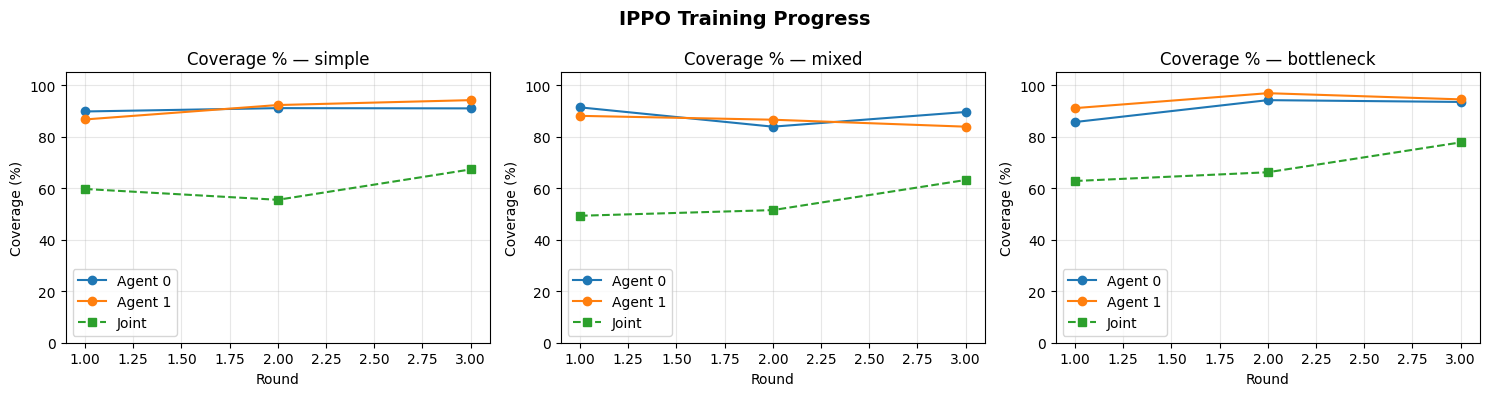

Saved → training_progress.png


In [8]:
# ── 7c. Training progress plot ───────────────────────────────────────────────
def plot_training_progress(eval_history: list) -> None:
    if not eval_history:
        print("No eval history yet.")
        return

    rounds = [r["round"] for r in eval_history]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    map_names = ["simple", "mixed", "bottleneck"]

    for ax, mname in zip(axes, map_names):
        for agent_id in range(2):
            key = f"agent{agent_id}"
            vals = [r[key][mname] for r in eval_history]
            ax.plot(rounds, vals, marker="o", label=f"Agent {agent_id}")
        joint_vals = [r["joint"][mname] for r in eval_history]
        ax.plot(rounds, joint_vals, marker="s", linestyle="--", label="Joint")
        ax.set_title(f"Coverage % — {mname}")
        ax.set_xlabel("Round")
        ax.set_ylabel("Coverage (%)")
        ax.set_ylim(0, 105)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle("IPPO Training Progress", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{BACKUP_DIR}/training_progress.png", dpi=120)
    plt.show()
    print("Saved → training_progress.png")

plot_training_progress(trainer.eval_history)



=== Final State ===
   0 1 2 3 4 5 6 7 8 9
 0 * * * * * * * * * 1
 1 * * * * . . * * * .
 2 * * # # * * * * * 0
 3 * * . . * * . * * .
 4 # # # # * # # # # #
 5 . * * * * . . . . .
 6 . * * * * * # # . .
 7 . . . . * * * . . .
 8 . # # # * * * . . .
 9 . . . . . * * * * *
Coverage: 61.9%  Steps: 800  UAV0: [2, 9]  UAV1: [0, 9]


Trajectory  (agent-0: lowercase, agent-1: UPPERCASE)
Z Z Z Z Z Z Z Z Z Z
Z Z Z Z     Z Z Y  
Z Z # # z I J K T z
Z Z     G H   R S  
# # # # F # # # # #
  z A B E          
  z z z D z # #    
        d z b      
  # # # e z z      
          g z y w v


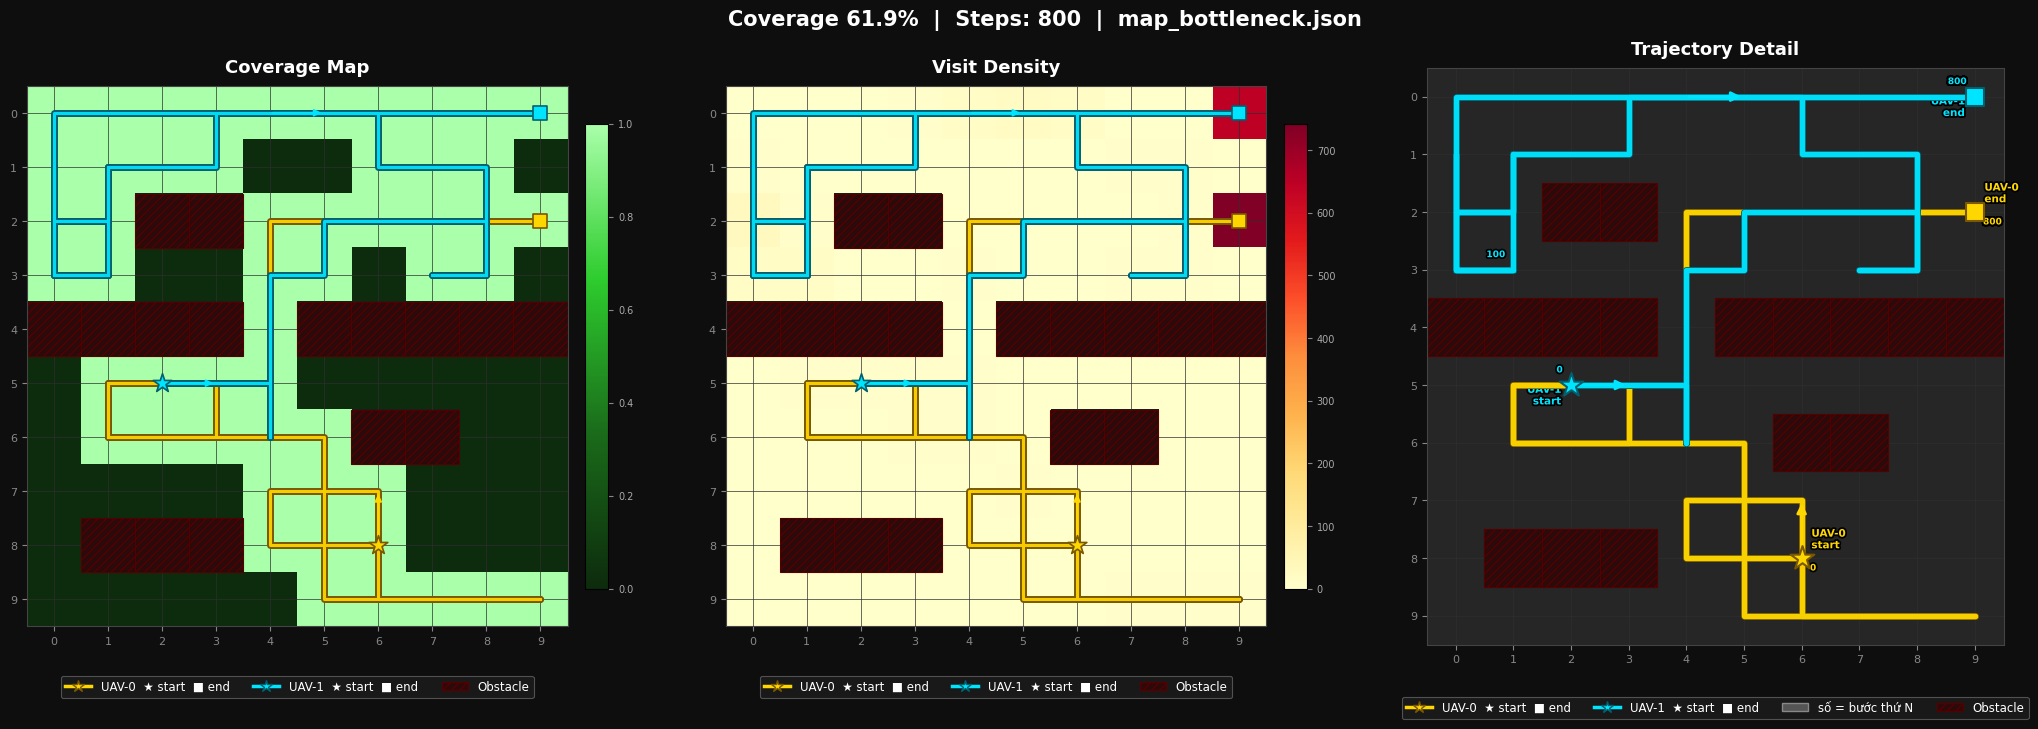

Saved → /kaggle/working/checkpoints_ippo/ippo_coverage_heatmap.png


In [9]:
# -- 7d. Render one episode with trajectory ----------------------------------
def render_episode(model_0, model_1, map_file: str, seed: int = 0) -> None:
    env = UAVPatrolEnvIPPO(map_file=map_file)
    obs, _ = env.reset(seed=seed)
    done = False
    while not done:
        a0, _ = model_0.predict(obs[0], deterministic=True)
        a1, _ = model_1.predict(obs[1], deterministic=True)
        obs, _, t, tr, _ = env.step([int(a0), int(a1)])
        done = t or tr
    print("\n=== Final State ===")
    env.render()
    print()
    env.render_trajectory()


# -- 7e. Coverage heatmap: legend nằm dưới mỗi panel, màu UAV tách biệt -----
def plot_coverage_heatmap(model_0, model_1, map_file: str, seed: int = 0) -> None:
    import matplotlib.patches as mpatches
    import matplotlib.patheffects as pe
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.lines import Line2D

    # ── Run episode ──────────────────────────────────────────────────────────
    env = UAVPatrolEnvIPPO(map_file=map_file)
    obs, _ = env.reset(seed=seed)
    done = False
    while not done:
        a0, _ = model_0.predict(obs[0], deterministic=True)
        a1, _ = model_1.predict(obs[1], deterministic=True)
        obs, _, t, tr, _ = env.step([int(a0), int(a1)])
        done = t or tr

    g       = env.grid_size
    cov_pct = env.coverage.sum() / env.free_cells
    n_steps = env.steps

    # ── Màu UAV: vàng rực vs cyan sáng — tương phản tối đa trên nền tối ────
    UAV_COLORS  = ["#FFD700", "#00E5FF"]   # gold / electric cyan
    UAV_OUTLINES= ["#7A5800", "#006070"]   # viền tối cùng tone
    UAV_LABELS  = ["UAV-0",   "UAV-1"]
    OBS_COLOR   = "#2A0A0A"
    OBS_HATCH   = "////"
    ARROW_EVERY = max(1, n_steps // 12)
    LABEL_EVERY = max(1, n_steps // 8)

    # ── Build arrays ─────────────────────────────────────────────────────────
    obs_mask   = np.zeros((g, g), dtype=bool)
    for o in env.obstacles:
        obs_mask[o] = True
    cov_disp   = np.where(obs_mask, np.nan, env.coverage.astype(float))
    visit_disp = np.where(obs_mask, np.nan, env.visit_count.astype(float))

    cov_cmap = LinearSegmentedColormap.from_list(
        "cov", ["#0D2B0D", "#1A6B1A", "#2ECC2E", "#AAFFAA"], N=256
    )

    # ── Figure 1 row × 3 panels ──────────────────────────────────────────────
    fig, axes_row = plt.subplots(
        1, 3, figsize=(21, 7.5), facecolor="#0E0E0E"
    )
    fig.patch.set_facecolor("#0E0E0E")

    panel_titles = ["Coverage Map", "Visit Density", "Trajectory Detail"]
    axes = list(axes_row)

    for ax, title in zip(axes, panel_titles):
        ax.set_facecolor("#1C1C1C")
        ax.set_title(title, color="white", fontsize=13,
                     fontweight="bold", pad=10)
        ax.set_xticks(range(g));  ax.set_yticks(range(g))
        ax.tick_params(colors="#888888", labelsize=8)
        ax.grid(True, color="#2E2E2E", linewidth=0.5, zorder=0)
        for sp in ax.spines.values():
            sp.set_edgecolor("#444444")

    ax_cov, ax_vis, ax_traj = axes

    # ── Helper: obstacle overlay ─────────────────────────────────────────────
    def _draw_obstacles(ax):
        for (r, c) in env.obstacles:
            ax.add_patch(plt.Rectangle(
                (c - 0.5, r - 0.5), 1, 1,
                facecolor=OBS_COLOR, hatch=OBS_HATCH,
                edgecolor="#550000", linewidth=0.8, zorder=2
            ))

    # ── Helper: legend dưới mỗi panel ────────────────────────────────────────
    def _add_legend(ax, show_steps=False):
        handles = []
        for color, label in zip(UAV_COLORS, UAV_LABELS):
            handles.append(Line2D(
                [0], [0], color=color, linewidth=2.5,
                marker="*", markersize=9,
                markerfacecolor=color, markeredgecolor=UAV_OUTLINES[UAV_COLORS.index(color)],
                label=f"{label}  ★ start  ■ end"
            ))
        if show_steps:
            handles.append(mpatches.Patch(
                facecolor="#555555", edgecolor="#888888",
                label="số = bước thứ N"
            ))
        handles.append(mpatches.Patch(
            facecolor=OBS_COLOR, hatch=OBS_HATCH,
            edgecolor="#550000", label="Obstacle"
        ))
        leg = ax.legend(
            handles=handles,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.08),   # dưới panel, ngoài bản đồ
            ncol=len(handles),
            fontsize=8.5,
            facecolor="#1A1A1A",
            edgecolor="#555555",
            labelcolor="white",
            framealpha=0.95,
            handlelength=2.2,
        )
        leg.get_frame().set_linewidth(0.8)

    # ── Panel 1: Coverage ────────────────────────────────────────────────────
    im_cov = ax_cov.imshow(
        np.ma.masked_invalid(cov_disp),
        cmap=cov_cmap, vmin=0, vmax=1,
        origin="upper", interpolation="nearest"
    )
    _draw_obstacles(ax_cov)
    cb1 = plt.colorbar(im_cov, ax=ax_cov, fraction=0.04, pad=0.03)
    cb1.ax.yaxis.set_tick_params(color="#888888")
    plt.setp(cb1.ax.yaxis.get_ticklabels(), color="#AAAAAA", fontsize=7)

    # ── Panel 2: Visit density ────────────────────────────────────────────────
    im_vis = ax_vis.imshow(
        np.ma.masked_invalid(visit_disp),
        cmap="YlOrRd", origin="upper", interpolation="nearest"
    )
    _draw_obstacles(ax_vis)
    cb2 = plt.colorbar(im_vis, ax=ax_vis, fraction=0.04, pad=0.03)
    cb2.ax.yaxis.set_tick_params(color="#888888")
    plt.setp(cb2.ax.yaxis.get_ticklabels(), color="#AAAAAA", fontsize=7)

    # ── Panel 3: Trajectory detail ────────────────────────────────────────────
    free_bg = np.where(obs_mask, np.nan, 0.15)
    ax_traj.imshow(
        np.ma.masked_invalid(free_bg),
        cmap="gray", vmin=0, vmax=1,
        origin="upper", interpolation="nearest"
    )
    _draw_obstacles(ax_traj)

    # ── Vẽ trajectory lên cả 3 panel ─────────────────────────────────────────
    for i, (traj, color, outline) in enumerate(
        zip(env.trajectory, UAV_COLORS, UAV_OUTLINES)
    ):
        xs = np.array([p[1] for p in traj], dtype=float)
        ys = np.array([p[0] for p in traj], dtype=float)
        stroke_fx = [pe.Stroke(linewidth=5, foreground=outline), pe.Normal()]

        # Panel 1 & 2: đường mỏng + mũi tên + start/end marker
        for ax in (ax_cov, ax_vis):
            ax.plot(xs, ys, color=color, linewidth=2.2,
                    alpha=0.92, zorder=10, path_effects=stroke_fx)
            for k in range(0, len(xs) - 1, ARROW_EVERY):
                dx = xs[k+1] - xs[k]; dy = ys[k+1] - ys[k]
                if abs(dx) + abs(dy) < 0.01:
                    continue
                ax.annotate("",
                    xy=(xs[k+1], ys[k+1]), xytext=(xs[k], ys[k]),
                    arrowprops=dict(arrowstyle="-|>", color=color,
                                    lw=1.4, mutation_scale=10),
                    zorder=11)
            ax.scatter(xs[0],  ys[0],  color=color, marker="*", s=200,
                       zorder=12, edgecolors=outline, linewidths=1.2)
            ax.scatter(xs[-1], ys[-1], color=color, marker="s", s=100,
                       zorder=12, edgecolors=outline, linewidths=1.2)

        # Panel 3: đường dày + số bước + start/end label rõ
        ax_traj.plot(xs, ys, color=color, linewidth=3.8,
                     alpha=0.95, zorder=10, path_effects=stroke_fx)
        for k in range(0, len(xs) - 1, ARROW_EVERY):
            dx = xs[k+1] - xs[k]; dy = ys[k+1] - ys[k]
            if abs(dx) + abs(dy) < 0.01:
                continue
            ax_traj.annotate("",
                xy=(xs[k+1], ys[k+1]), xytext=(xs[k], ys[k]),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=2.0, mutation_scale=14),
                zorder=11)

        # Số bước — offset ngược hướng để 2 UAV không đè nhau
        txt_offset = (6, -9) if i == 0 else (-6, 9)
        txt_ha     = "left"  if i == 0 else "right"
        for k in range(0, len(xs), LABEL_EVERY):
            ax_traj.annotate(
                str(k), xy=(xs[k], ys[k]),
                xytext=txt_offset, textcoords="offset points",
                fontsize=6.5, color=color, fontweight="bold",
                ha=txt_ha, zorder=13,
                path_effects=[
                    pe.Stroke(linewidth=2.5, foreground="#000000"),
                    pe.Normal()
                ]
            )

        # Start ★ / End ■
        ax_traj.scatter(xs[0],  ys[0],  color=color, marker="*",
                        s=320, zorder=14, edgecolors=outline, linewidths=1.5)
        ax_traj.scatter(xs[-1], ys[-1], color=color, marker="s",
                        s=150, zorder=14, edgecolors=outline, linewidths=1.5)

        # Label start/end — offset ngược nhau
        lbl_offset = (7, 7) if i == 0 else (-7, -14)
        lbl_ha     = "left" if i == 0 else "right"
        ax_traj.annotate(
            f"{UAV_LABELS[i]}\nstart",
            xy=(xs[0], ys[0]),
            xytext=lbl_offset, textcoords="offset points",
            fontsize=7.5, color=color, fontweight="bold", ha=lbl_ha,
            path_effects=[pe.Stroke(linewidth=2.5, foreground="#000000"),
                          pe.Normal()]
        )
        ax_traj.annotate(
            f"{UAV_LABELS[i]}\nend",
            xy=(xs[-1], ys[-1]),
            xytext=lbl_offset, textcoords="offset points",
            fontsize=7.5, color=color, fontweight="bold", ha=lbl_ha,
            path_effects=[pe.Stroke(linewidth=2.5, foreground="#000000"),
                          pe.Normal()]
        )

    # ── Legend dưới mỗi panel (ngoài bản đồ) ─────────────────────────────────
    _add_legend(ax_cov,  show_steps=False)
    _add_legend(ax_vis,  show_steps=False)
    _add_legend(ax_traj, show_steps=True)

    # ── Super-title ───────────────────────────────────────────────────────────
    fig.suptitle(
        f"Coverage {cov_pct:.1%}  |  Steps: {n_steps}  |  {map_file.split('/')[-1]}",
        fontsize=15, fontweight="bold", color="white", y=1.01
    )

    # rect bottom=0.12 để chừa chỗ cho legend bên dưới
    plt.tight_layout(rect=[0, 0.12, 1, 1])

    out_path = f"{BACKUP_DIR}/ippo_coverage_heatmap.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {out_path}")


render_episode(trainer.models[0], trainer.models[1], MAP_PATHS["bottleneck"])
plot_coverage_heatmap(trainer.models[0], trainer.models[1], MAP_PATHS["bottleneck"])

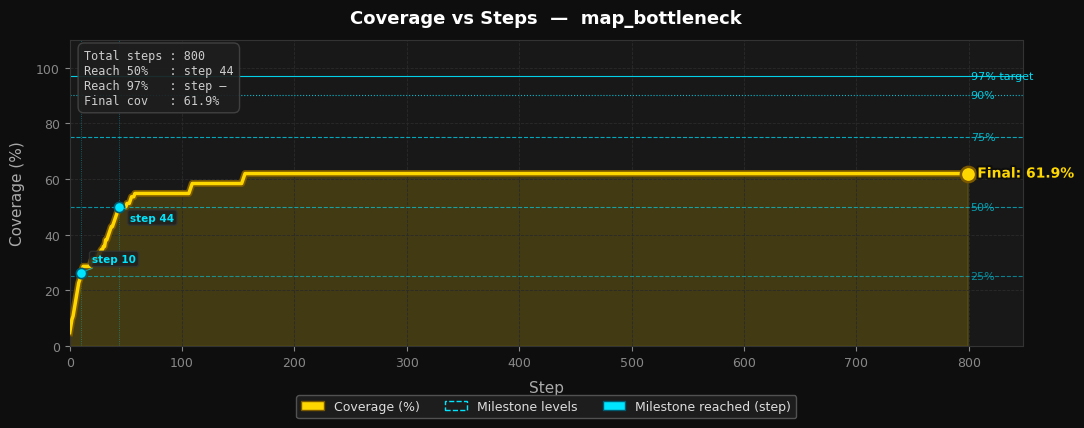

Saved → /kaggle/working/checkpoints_ippo/ippo_coverage_vs_steps.png


In [10]:
# -- Coverage vs Steps --------------------------------------------------------
def plot_coverage_vs_steps(model_0, model_1, map_file: str, seed: int = 0):
    import matplotlib.patches as mpatches
    import matplotlib.patheffects as pe
    from matplotlib.colors import LinearSegmentedColormap

    # ── Run episode ──────────────────────────────────────────────────────────
    env = UAVPatrolEnvIPPO(map_file=map_file)
    obs, _ = env.reset(seed=seed)
    done = False
    coverage_history = []
    milestone_steps  = {}   # step đạt các mốc 25/50/75/90/97%

    while not done:
        a0, _ = model_0.predict(obs[0], deterministic=True)
        a1, _ = model_1.predict(obs[1], deterministic=True)
        obs, _, t, tr, _ = env.step([int(a0), int(a1)])
        cov = env.coverage.sum() / env.free_cells * 100
        coverage_history.append(cov)
        for m in [25, 50, 75, 90, 97]:
            if m not in milestone_steps and cov >= m:
                milestone_steps[m] = len(coverage_history) - 1
        done = t or tr

    steps     = np.arange(len(coverage_history))
    cov_arr   = np.array(coverage_history)
    final_cov = cov_arr[-1]
    map_name  = map_file.split("/")[-1].replace(".json", "")

    # ── Style ────────────────────────────────────────────────────────────────
    BG        = "#0E0E0E"
    PANEL     = "#181818"
    GRID_CLR  = "#2A2A2A"
    LINE_CLR  = "#FFD700"      # gold — tương phản trên nền tối
    FILL_TOP  = "#FFD70033"
    FILL_BOT  = "#FFD70005"
    MILE_CLR  = "#00E5FF"      # cyan cho milestone lines
    ANNO_BG   = "#1E1E1E"

    fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor("#333333")

    # ── Gradient fill dưới đường ─────────────────────────────────────────────
    # Dùng polygon alpha thay gradient (matplotlib-safe)
    ax.fill_between(steps, cov_arr, alpha=0.18, color=LINE_CLR, zorder=1)

    # ── Đường chính với outline ───────────────────────────────────────────────
    stroke_fx = [pe.Stroke(linewidth=5, foreground="#7A5800"), pe.Normal()]
    ax.plot(steps, cov_arr, color=LINE_CLR, linewidth=2.5,
            zorder=5, path_effects=stroke_fx, label="Coverage")

    # ── Milestone horizontal lines ────────────────────────────────────────────
    mile_styles = {
        25: ("--", 0.5, "25%"),
        50: ("--", 0.6, "50%"),
        75: ("--", 0.7, "75%"),
        90: (  ":", 0.8, "90%"),
        97: (  "-", 0.9, "97% target"),
    }
    for m, (ls, alpha, lbl) in mile_styles.items():
        ax.axhline(m, color=MILE_CLR, linewidth=0.8,
                   linestyle=ls, alpha=alpha, zorder=2)
        ax.text(len(steps) * 1.002, m, lbl,
                color=MILE_CLR, fontsize=8, va="center",
                alpha=alpha + 0.05)

    # ── Vertical markers tại bước đạt milestone ───────────────────────────────
    for m, step_idx in milestone_steps.items():
        ax.axvline(step_idx, color=MILE_CLR, linewidth=0.6,
                   linestyle=":", alpha=0.45, zorder=2)
        ax.scatter(step_idx, cov_arr[step_idx],
                   color=MILE_CLR, s=55, zorder=8,
                   edgecolors="#005A70", linewidths=1.2)
        # Annotation box
        offset_y = -10 if m in [50, 90] else 8   # tránh đụng nhau
        ax.annotate(
            f"step {step_idx}",
            xy=(step_idx, cov_arr[step_idx]),
            xytext=(8, offset_y), textcoords="offset points",
            fontsize=7.5, color=MILE_CLR, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", fc=ANNO_BG,
                      ec="#333333", alpha=0.85),
            arrowprops=dict(arrowstyle="-", color=MILE_CLR,
                            lw=0.7, alpha=0.6),
            zorder=9,
        )

    # ── Điểm cuối nổi bật ────────────────────────────────────────────────────
    ax.scatter(steps[-1], final_cov, color=LINE_CLR, s=120,
               zorder=10, edgecolors="#7A5800", linewidths=1.8)
    ax.annotate(
        f"  Final: {final_cov:.1f}%",
        xy=(steps[-1], final_cov),
        fontsize=10, color=LINE_CLR, fontweight="bold",
        va="center",
        path_effects=[pe.Stroke(linewidth=3, foreground=BG), pe.Normal()],
        zorder=11,
    )

    # ── Axes ─────────────────────────────────────────────────────────────────
    ax.set_xlim(0, len(steps) * 1.06)
    ax.set_ylim(0, 110)
    ax.set_xlabel("Step", color="#AAAAAA", fontsize=11, labelpad=8)
    ax.set_ylabel("Coverage (%)", color="#AAAAAA", fontsize=11, labelpad=8)
    ax.tick_params(colors="#888888", labelsize=9)
    ax.grid(True, color=GRID_CLR, linewidth=0.6, linestyle="--",
            axis="both", zorder=0)

    # ── Stats box (góc trên trái) ─────────────────────────────────────────────
    total_steps = len(steps)
    step_50  = milestone_steps.get(50,  "—")
    step_97  = milestone_steps.get(97,  "—")
    stats_txt = (
        f"Total steps : {total_steps}\n"
        f"Reach 50%   : step {step_50}\n"
        f"Reach 97%   : step {step_97}\n"
        f"Final cov   : {final_cov:.1f}%"
    )
    ax.text(
        0.015, 0.97, stats_txt,
        transform=ax.transAxes,
        fontsize=8.5, color="#CCCCCC",
        va="top", ha="left", family="monospace",
        bbox=dict(boxstyle="round,pad=0.5", fc=ANNO_BG,
                  ec="#444444", alpha=0.92),
        zorder=12,
    )

    # ── Title ────────────────────────────────────────────────────────────────
    ax.set_title(
        f"Coverage vs Steps  —  {map_name}",
        fontsize=13, fontweight="bold", color="white", pad=12
    )

    # ── Legend dưới biểu đồ ──────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=LINE_CLR,  edgecolor="#7A5800",
                       label="Coverage (%)"),
        mpatches.Patch(facecolor="none",    edgecolor=MILE_CLR,
                       linestyle="--",      label="Milestone levels"),
        mpatches.Patch(facecolor=MILE_CLR,  edgecolor="#005A70",
                       label="Milestone reached (step)"),
    ]
    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.14),
        ncol=3,
        fontsize=9,
        facecolor=ANNO_BG,
        edgecolor="#555555",
        labelcolor="#DDDDDD",
        framealpha=0.95,
        handlelength=1.8,
    )

    plt.tight_layout(rect=[0, 0.10, 1, 1])

    out_path = f"{BACKUP_DIR}/ippo_coverage_vs_steps.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {out_path}")


plot_coverage_vs_steps(trainer.models[0], trainer.models[1], MAP_PATHS["bottleneck"])

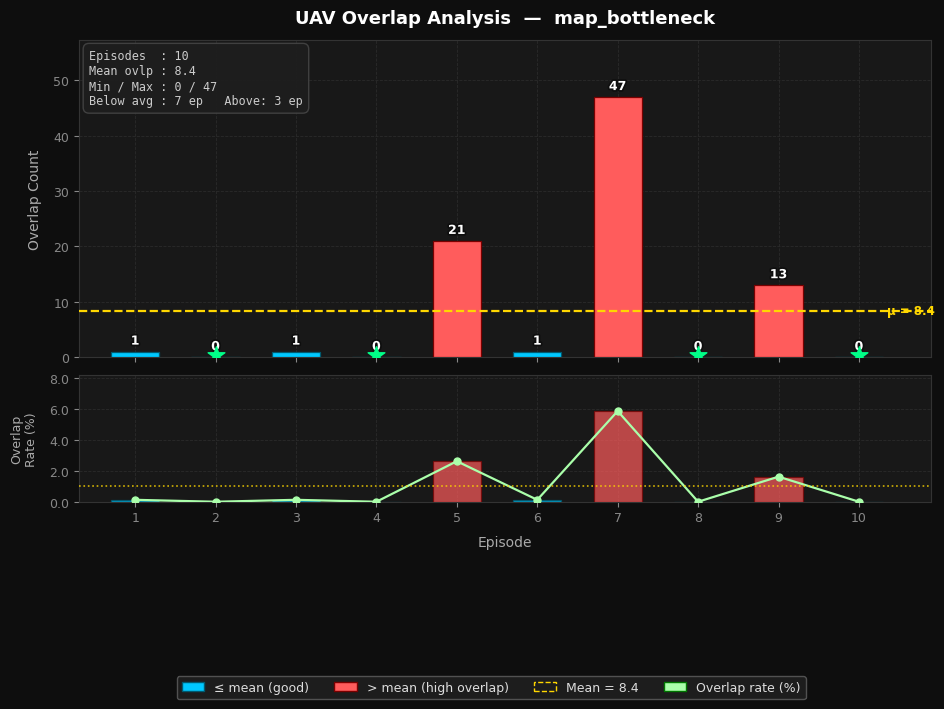

Saved → /kaggle/working/checkpoints_ippo/ippo_overlap_analysis.png


In [11]:
# -- Overlap Analysis ---------------------------------------------------------
def plot_overlap_analysis(model_0, model_1, map_file: str, episodes: int = 10):
    import matplotlib.patches as mpatches
    import matplotlib.patheffects as pe
    import matplotlib.ticker as ticker

    # ── Run episodes, collect per-episode stats ───────────────────────────────
    overlap_counts  = []
    coverage_finals = []
    step_counts     = []

    for ep in range(episodes):
        env = UAVPatrolEnvIPPO(map_file=map_file)
        obs, _ = env.reset(seed=ep)
        done = False
        overlap = 0
        while not done:
            a0, _ = model_0.predict(obs[0], deterministic=True)
            a1, _ = model_1.predict(obs[1], deterministic=True)
            obs, _, t, tr, _ = env.step([int(a0), int(a1)])
            p0, p1 = env.agent_positions
            if check_collision(p0, p1) or check_overlap(p0, p1):
                overlap += 1
            done = t or tr
        overlap_counts.append(overlap)
        coverage_finals.append(env.coverage.sum() / env.free_cells * 100)
        step_counts.append(env.steps)

    eps       = np.arange(1, episodes + 1)
    counts    = np.array(overlap_counts, dtype=float)
    mean_ovlp = counts.mean()
    map_name  = map_file.split("/")[-1].replace(".json", "")

    # ── Style ─────────────────────────────────────────────────────────────────
    BG       = "#0E0E0E"
    PANEL    = "#181818"
    GRID_CLR = "#2A2A2A"
    ANNO_BG  = "#1E1E1E"

    # Bar colour: cyan nếu dưới mean, coral nếu trên mean
    BAR_LOW  = "#00C8FF"   # dưới trung bình → tốt
    BAR_HIGH = "#FF5C5C"   # trên trung bình → xấu
    MEAN_CLR = "#FFD700"   # gold cho đường mean
    RATE_CLR = "#AAFFAA"   # xanh lá nhạt cho overlap rate

    bar_colors = [BAR_HIGH if c > mean_ovlp else BAR_LOW for c in counts]
    outline_colors = ["#7A0000" if c == BAR_HIGH else "#005A70"
                      for c in bar_colors]

    # ── Figure: 2 panels (bar + rate line) ────────────────────────────────────
    fig, (ax_bar, ax_rate) = plt.subplots(
        2, 1, figsize=(11, 7),
        facecolor=BG,
        gridspec_kw={"height_ratios": [3, 1.2], "hspace": 0.08}
    )
    for ax in (ax_bar, ax_rate):
        ax.set_facecolor(PANEL)
        for sp in ax.spines.values():
            sp.set_edgecolor("#333333")
        ax.grid(True, color=GRID_CLR, linewidth=0.6,
                linestyle="--", zorder=0)
        ax.tick_params(colors="#888888", labelsize=9)

    # ── Panel 1: Bar chart ────────────────────────────────────────────────────
    bars = ax_bar.bar(
        eps, counts,
        color=bar_colors, edgecolor=outline_colors,
        linewidth=0.9, width=0.6, zorder=4
    )

    # Value label trên mỗi bar
    for bar, val in zip(bars, counts):
        ypos = bar.get_height() + max(counts) * 0.015
        ax_bar.text(
            bar.get_x() + bar.get_width() / 2, ypos,
            str(int(val)),
            ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="white",
            path_effects=[pe.Stroke(linewidth=2.5, foreground=BG),
                          pe.Normal()],
            zorder=6
        )

    # Mean line
    ax_bar.axhline(mean_ovlp, color=MEAN_CLR, linewidth=1.6,
                   linestyle="--", zorder=5, label=f"Mean {mean_ovlp:.1f}")
    ax_bar.text(
        episodes + 0.35, mean_ovlp,
        f"μ = {mean_ovlp:.1f}",
        color=MEAN_CLR, fontsize=8.5, va="center", fontweight="bold"
    )

    # Zero-overlap marker nếu có episode nào = 0
    zero_eps = [e for e, c in zip(eps, counts) if c == 0]
    if zero_eps:
        ax_bar.scatter(zero_eps, [0.3] * len(zero_eps),
                       color="#00FF88", marker="*", s=160,
                       zorder=7, label="Zero overlap")

    ax_bar.set_xlim(0.3, episodes + 0.9)
    ax_bar.set_ylim(0, max(counts) * 1.22 if max(counts) > 0 else 5)
    ax_bar.set_ylabel("Overlap Count", color="#AAAAAA", fontsize=10, labelpad=8)
    ax_bar.set_xticks(eps)
    ax_bar.set_xticklabels([])   # ẩn, panel dưới đã có

    ax_bar.set_title(
        f"UAV Overlap Analysis  —  {map_name}",
        fontsize=13, fontweight="bold", color="white", pad=12
    )

    # Stats box
    n_low  = sum(1 for c in counts if c <= mean_ovlp)
    n_high = episodes - n_low
    stats_txt = (
        f"Episodes  : {episodes}\n"
        f"Mean ovlp : {mean_ovlp:.1f}\n"
        f"Min / Max : {int(min(counts))} / {int(max(counts))}\n"
        f"Below avg : {n_low} ep   Above: {n_high} ep"
    )
    ax_bar.text(
        0.012, 0.97, stats_txt,
        transform=ax_bar.transAxes,
        fontsize=8.5, color="#CCCCCC",
        va="top", ha="left", family="monospace",
        bbox=dict(boxstyle="round,pad=0.5", fc=ANNO_BG,
                  ec="#444444", alpha=0.92),
        zorder=8,
    )

    # ── Panel 2: Overlap rate (%) per episode ─────────────────────────────────
    rates = counts / np.array(step_counts) * 100   # overlap / total steps

    ax_rate.bar(eps, rates, color=bar_colors, edgecolor=outline_colors,
                linewidth=0.9, width=0.6, alpha=0.7, zorder=4)
    ax_rate.plot(eps, rates, color=RATE_CLR, linewidth=1.6,
                 marker="o", markersize=5, zorder=5)
    ax_rate.axhline(rates.mean(), color=MEAN_CLR, linewidth=1.2,
                    linestyle=":", alpha=0.8, zorder=5)

    ax_rate.set_xlim(0.3, episodes + 0.9)
    ax_rate.set_ylim(0, max(rates) * 1.4 if max(rates) > 0 else 1)
    ax_rate.set_ylabel("Overlap\nRate (%)", color="#AAAAAA",
                       fontsize=9, labelpad=8)
    ax_rate.set_xlabel("Episode", color="#AAAAAA", fontsize=10, labelpad=8)
    ax_rate.set_xticks(eps)
    ax_rate.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

    # ── Legend dưới biểu đồ ───────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=BAR_LOW,  edgecolor="#005A70",
                       label=f"≤ mean (good)"),
        mpatches.Patch(facecolor=BAR_HIGH, edgecolor="#7A0000",
                       label=f"> mean (high overlap)"),
        mpatches.Patch(facecolor="none",   edgecolor=MEAN_CLR,
                       linestyle="--",     label=f"Mean = {mean_ovlp:.1f}"),
        mpatches.Patch(facecolor=RATE_CLR, edgecolor="#007700",
                       label="Overlap rate (%)"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=4,
        fontsize=9,
        facecolor=ANNO_BG,
        edgecolor="#555555",
        labelcolor="#DDDDDD",
        framealpha=0.95,
        handlelength=1.8,
    )

    fig.subplots_adjust(bottom=0.22)

    out_path = f"{BACKUP_DIR}/ippo_overlap_analysis.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {out_path}")


plot_overlap_analysis(trainer.models[0], trainer.models[1], MAP_PATHS["bottleneck"])

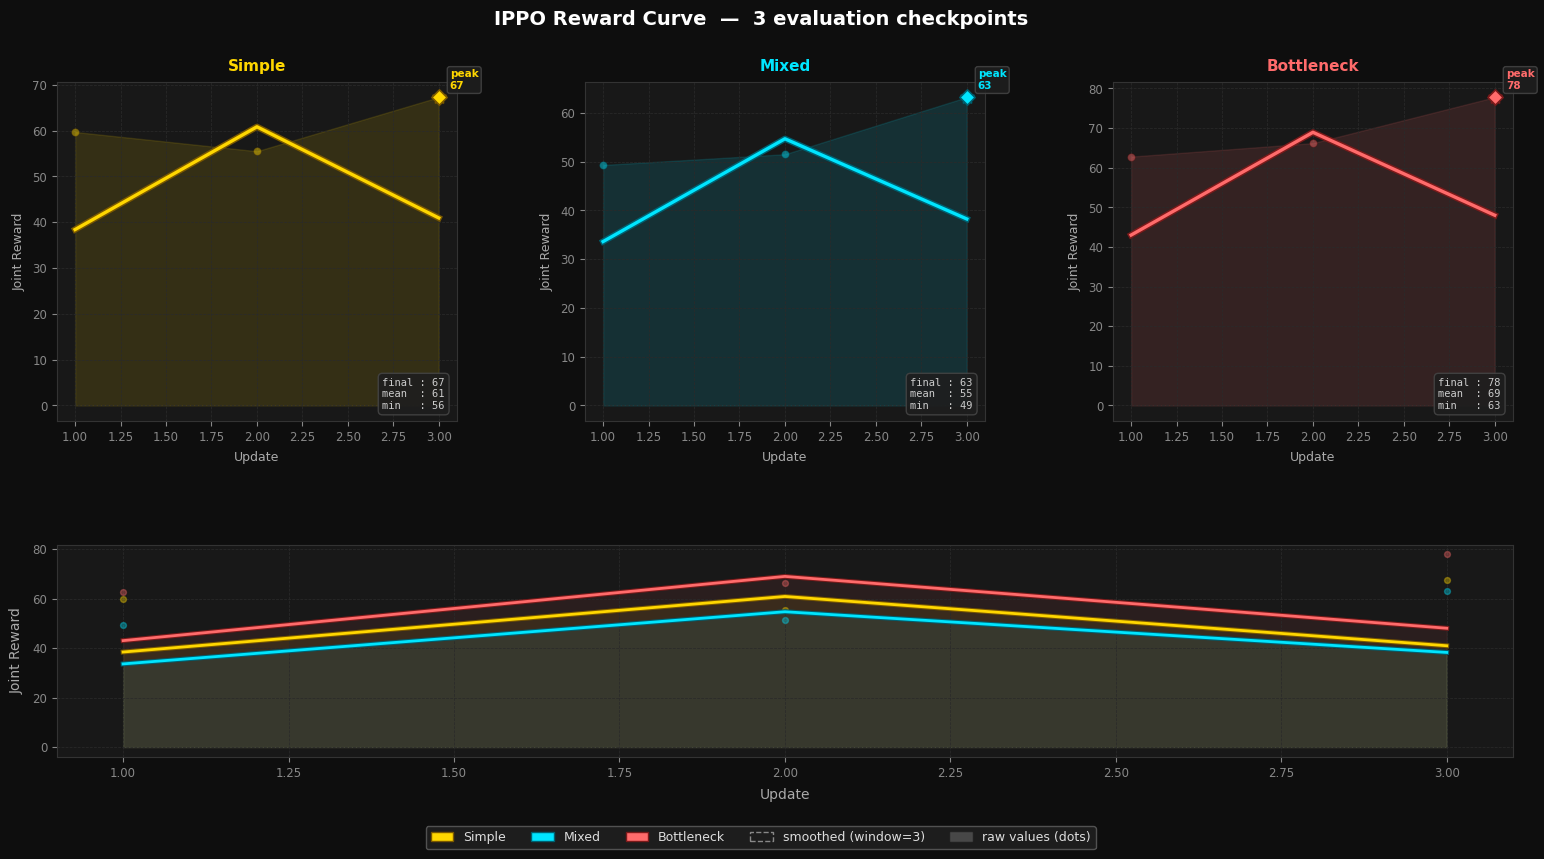

Saved → /kaggle/working/checkpoints_ippo/ippo_reward_curve.png


In [12]:
# -- Reward Curve -------------------------------------------------------------
def plot_reward_curve(eval_history):
    if not eval_history:
        print("No eval history.")
        return

    import matplotlib.patches as mpatches
    import matplotlib.patheffects as pe
    import matplotlib.ticker as ticker
    from matplotlib.gridspec import GridSpec

    # ── Data ─────────────────────────────────────────────────────────────────
    updates   = [r["round"] for r in eval_history]
    map_names = ["simple", "mixed", "bottleneck"]
    map_colors = {
        "simple":     "#FFD700",   # gold
        "mixed":      "#00E5FF",   # cyan
        "bottleneck": "#FF6B6B",   # coral
    }
    map_outlines = {
        "simple":     "#7A5800",
        "mixed":      "#006070",
        "bottleneck": "#7A1A1A",
    }

    # ── Style ─────────────────────────────────────────────────────────────────
    BG       = "#0E0E0E"
    PANEL    = "#181818"
    GRID_CLR = "#2A2A2A"
    ANNO_BG  = "#1E1E1E"

    # ── Figure: 3 panels trên + 1 panel tổng hợp dưới ────────────────────────
    fig = plt.figure(figsize=(16, 9), facecolor=BG)
    fig.patch.set_facecolor(BG)

    gs = GridSpec(
        2, 3,
        figure=fig,
        hspace=0.45, wspace=0.32,
        top=0.88, bottom=0.13,
        left=0.06, right=0.97,
        height_ratios=[1.6, 1.0],
    )

    axes_top    = [fig.add_subplot(gs[0, i]) for i in range(3)]
    ax_combined = fig.add_subplot(gs[1, :])   # full-width bottom panel

    # ── Helper: style one axes ────────────────────────────────────────────────
    def _style(ax):
        ax.set_facecolor(PANEL)
        for sp in ax.spines.values():
            sp.set_edgecolor("#333333")
        ax.grid(True, color=GRID_CLR, linewidth=0.55,
                linestyle="--", zorder=0)
        ax.tick_params(colors="#888888", labelsize=8.5)

    for ax in axes_top + [ax_combined]:
        _style(ax)

    # ── Helper: smooth line (running mean window) ─────────────────────────────
    def _smooth(arr, w=3):
        if len(arr) < w:
            return np.array(arr, dtype=float)
        kernel = np.ones(w) / w
        return np.convolve(arr, kernel, mode="same")

    # ── Panel trên: 1 map per panel ───────────────────────────────────────────
    for ax, mname in zip(axes_top, map_names):
        color   = map_colors[mname]
        outline = map_outlines[mname]
        rewards = np.array([r["joint"][mname] for r in eval_history], dtype=float)
        smooth  = _smooth(rewards, w=3)
        stroke  = [pe.Stroke(linewidth=4.5, foreground=outline), pe.Normal()]

        # Fill dưới đường
        ax.fill_between(updates, rewards, alpha=0.12, color=color, zorder=1)

        # Raw dots mờ
        ax.scatter(updates, rewards, color=color, s=28, alpha=0.45,
                   zorder=3, edgecolors=outline, linewidths=0.6)

        # Smoothed line nổi bật
        ax.plot(updates, smooth, color=color, linewidth=2.4,
                zorder=4, path_effects=stroke)

        # Đỉnh cao nhất
        peak_idx = int(np.argmax(rewards))
        ax.scatter(updates[peak_idx], rewards[peak_idx],
                   color=color, s=90, zorder=6,
                   edgecolors=outline, linewidths=1.5,
                   marker="*")
        ax.annotate(
            f"peak\n{rewards[peak_idx]:,.0f}",
            xy=(updates[peak_idx], rewards[peak_idx]),
            xytext=(8, 6), textcoords="offset points",
            fontsize=7.5, color=color, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", fc=ANNO_BG,
                      ec="#444444", alpha=0.88),
            zorder=7,
        )

        # Điểm cuối
        ax.scatter(updates[-1], rewards[-1],
                   color=color, s=60, zorder=6,
                   edgecolors=outline, linewidths=1.2,
                   marker="D")

        # Stats box — góc dưới bên phải, trong axes
        stats = (
            f"final : {rewards[-1]:,.0f}\n"
            f"mean  : {rewards.mean():,.0f}\n"
            f"min   : {rewards.min():,.0f}"
        )
        ax.text(
            0.97, 0.03, stats,
            transform=ax.transAxes,
            fontsize=7.5, color="#CCCCCC",
            va="bottom", ha="right", family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", fc=ANNO_BG,
                      ec="#444444", alpha=0.90),
            zorder=8,
        )

        # Zero line nếu reward âm tồn tại
        if rewards.min() < 0 < rewards.max():
            ax.axhline(0, color="#555555", linewidth=0.8,
                       linestyle="-", zorder=2)

        ax.set_title(
            mname.capitalize(),
            fontsize=11, fontweight="bold",
            color=color, pad=8
        )
        ax.set_xlabel("Update", color="#AAAAAA", fontsize=9, labelpad=5)
        ax.set_ylabel("Joint Reward", color="#AAAAAA", fontsize=9, labelpad=5)
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
        )

    # ── Panel dưới: 3 map trên cùng trục (overview) ──────────────────────────
    for mname in map_names:
        color   = map_colors[mname]
        outline = map_outlines[mname]
        rewards = np.array([r["joint"][mname] for r in eval_history], dtype=float)
        smooth  = _smooth(rewards, w=3)
        stroke  = [pe.Stroke(linewidth=3.5, foreground=outline), pe.Normal()]

        ax_combined.fill_between(updates, smooth,
                                 alpha=0.08, color=color, zorder=1)
        ax_combined.plot(updates, smooth, color=color, linewidth=2.0,
                         zorder=4, path_effects=stroke, label=mname.capitalize())
        ax_combined.scatter(updates, rewards, color=color, s=18,
                            alpha=0.35, zorder=3)

    if any(
        [r["joint"][m] for r in eval_history
         for m in map_names if r["joint"][m] < 0]
    ):
        ax_combined.axhline(0, color="#555555", linewidth=0.8,
                            linestyle="-", zorder=2)

    ax_combined.set_xlabel("Update", color="#AAAAAA", fontsize=10, labelpad=6)
    ax_combined.set_ylabel("Joint Reward", color="#AAAAAA",
                            fontsize=10, labelpad=6)
    ax_combined.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )

    # ── Legend dưới combined panel ────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=map_colors[m], edgecolor=map_outlines[m],
                       label=m.capitalize())
        for m in map_names
    ] + [
        mpatches.Patch(facecolor="none", edgecolor="#888888",
                       linestyle="--", label="smoothed (window=3)"),
        mpatches.Patch(facecolor="#888888", edgecolor="#555555",
                       alpha=0.4, label="raw values (dots)"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.06),
        ncol=len(legend_handles),
        fontsize=9,
        facecolor=ANNO_BG,
        edgecolor="#555555",
        labelcolor="#DDDDDD",
        framealpha=0.95,
        handlelength=1.8,
    )

    # ── Super title ───────────────────────────────────────────────────────────
    n_updates = len(updates)
    fig.suptitle(
        f"IPPO Reward Curve  —  {n_updates} evaluation checkpoints",
        fontsize=14, fontweight="bold", color="white", y=0.96
    )

    out_path = f"{BACKUP_DIR}/ippo_reward_curve.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {out_path}")


plot_reward_curve(trainer.eval_history)

In [13]:
# ── Save all experiment artifacts ─────────────────────────────────────────────
import os, json, zipfile, pickle
from datetime import datetime

SAVE_DIR = "/kaggle/working/ippo_artifacts"
os.makedirs(SAVE_DIR, exist_ok=True)
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save SB3 models
for agent_id, model in trainer.models.items():
    model.save(f"{SAVE_DIR}/agent{agent_id}_final")
    print(f"  ✓ agent{agent_id} model saved")

# 2. Save eval history (JSON)
with open(f"{SAVE_DIR}/eval_history.json", "w") as f:
    json.dump(trainer.eval_history, f, indent=2, ensure_ascii=False)
print(f"  ✓ eval_history saved ({len(trainer.eval_history)} rounds)")

# 3. Save training config
config = {
    "map_file":              trainer.map_file,
    "train_steps_per_round": trainer.train_steps_per_round,
    "n_rounds":              trainer.n_rounds,
    "n_envs":                trainer.n_envs,
    "seed":                  trainer.seed,
    "timestamp":             TIMESTAMP,
    "map_paths":             MAP_PATHS,
}
with open(f"{SAVE_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print("  ✓ config saved")

# 4. Save final eval results across all maps
final_results = {}
for name, mp in MAP_PATHS.items():
    res = trainer._eval_joint(n_episodes=10)
    final_results[name] = res
    print(f"  ✓ eval {name}: {res}")
with open(f"{SAVE_DIR}/final_eval_results.json", "w") as f:
    json.dump(final_results, f, indent=2, ensure_ascii=False)

# 5. Save coverage/overlap/reward logs per map (raw arrays)
logs = {}
for name, mp in MAP_PATHS.items():
    covs, overlaps, rewards = [], [], []
    for ep in range(10):
        env = UAVPatrolEnvIPPO(map_file=mp)
        obs, _ = env.reset(seed=1000 + ep)
        done = False
        ep_reward = {0: 0.0, 1: 0.0}
        ep_overlap = 0
        while not done:
            actions = []
            for i in range(env.num_agents):
                if i in trainer.models:
                    act, _ = trainer.models[i].predict(obs[i], deterministic=True)
                    actions.append(int(act))
                else:
                    actions.append(env.single_action_space.sample())
            obs, rews, t, tr, info = env.step(actions)
            for i in range(env.num_agents):
                ep_reward[i] += rews[i]
            p0, p1 = env.agent_positions
            if check_collision(p0, p1) or check_overlap(p0, p1):
                ep_overlap += 1
            done = t or tr
        covs.append(float(env.coverage.sum() / env.free_cells * 100))
        overlaps.append(ep_overlap)
        rewards.append(float(ep_reward[0] + ep_reward[1]))
    logs[name] = {"coverage": covs, "overlap": overlaps, "joint_reward": rewards}
    print(f"  ✓ logs {name}: cov={sum(covs)/len(covs):.1f}%  ovlp={sum(overlaps)/len(overlaps):.1f}  r={sum(rewards)/len(rewards):.1f}")

with open(f"{SAVE_DIR}/episode_logs.json", "w") as f:
    json.dump(logs, f, indent=2, ensure_ascii=False)

# 6. Save map configs
os.makedirs(f"{SAVE_DIR}/maps", exist_ok=True)
for name, mp in MAP_PATHS.items():
    if os.path.exists(mp):
        import shutil
        shutil.copy(mp, f"{SAVE_DIR}/maps/{os.path.basename(mp)}")
print("  ✓ maps copied")

# 7. Copy plots if exist
PLOT_DIR = BACKUP_DIR  # /kaggle/working/checkpoints_ippo
os.makedirs(f"{SAVE_DIR}/plots", exist_ok=True)
for fname in os.listdir(PLOT_DIR):
    if fname.endswith(".png"):
        shutil.copy(f"{PLOT_DIR}/{fname}", f"{SAVE_DIR}/plots/{fname}")
n_plots = len([f for f in os.listdir(f"{SAVE_DIR}/plots") if f.endswith(".png")])
print(f"  ✓ {n_plots} plots copied")

# 8. Write summary README
readme = f"""# IPPO UAV Patrol — Experiment Artifacts
Generated: {TIMESTAMP}

## Files
- agent0_final.zip / agent1_final.zip  : SB3 PPO model weights
- config.json                          : training configuration
- eval_history.json                    : per-round eval metrics
- final_eval_results.json              : final joint eval (10 eps × 3 maps)
- episode_logs.json                    : raw coverage/overlap/reward per episode
- maps/                                : map JSON configs
- plots/                               : all generated figures

## Final Results
"""
for name, res in final_results.items():
    readme += f"- {name}: {res}\n"

with open(f"{SAVE_DIR}/README.md", "w") as f:
    f.write(readme)

# 9. Pack everything into a single zip
ZIP_PATH = f"/kaggle/working/ippo_experiment_{TIMESTAMP}.zip"
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(SAVE_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arc_name  = os.path.relpath(full_path, SAVE_DIR)
            zf.write(full_path, arc_name)

zip_size_mb = os.path.getsize(ZIP_PATH) / 1024 / 1024
print(f"\n{'='*55}")
print(f"  ✓ All artifacts saved → {ZIP_PATH}")
print(f"  📦 Size: {zip_size_mb:.1f} MB")
print(f"  📁 Contents:")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    for name in sorted(zf.namelist()):
        info = zf.getinfo(name)
        print(f"     {name:<45} {info.file_size/1024:>8.1f} KB")
print(f"{'='*55}")

  ✓ agent0 model saved
  ✓ agent1 model saved
  ✓ eval_history saved (3 rounds)
  ✓ config saved
  ✓ eval simple: {'simple': 75.8, 'mixed': 62.4, 'bottleneck': 74.5, 'mean': 70.9}
  ✓ eval mixed: {'simple': 75.1, 'mixed': 65.6, 'bottleneck': 67.4, 'mean': 69.4}
  ✓ eval bottleneck: {'simple': 68.5, 'mixed': 55.7, 'bottleneck': 67.5, 'mean': 63.9}
  ✓ logs simple: cov=83.8%  ovlp=6.0  r=18537.0
  ✓ logs mixed: cov=71.1%  ovlp=9.0  r=8746.2
  ✓ logs bottleneck: cov=69.4%  ovlp=4.7  r=17183.9
  ✓ maps copied
  ✓ 5 plots copied

  ✓ All artifacts saved → /kaggle/working/ippo_experiment_20260511_215132.zip
  📦 Size: 9.3 MB
  📁 Contents:
     README.md                                          0.8 KB
     agent0_final.zip                                4869.6 KB
     agent1_final.zip                                4869.6 KB
     config.json                                        0.4 KB
     episode_logs.json                                  1.9 KB
     eval_history.json                       